<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/neural_networks/Demo_Multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Multiclass image classification with an MLP (Fashion-MNIST)

The XOR labs had two classes and two input features. Real problems have many classes and many features. Here we classify $28 \times 28$ grayscale photos of clothes into **10 classes**. Each image is 784 numbers. Two new ideas make this work: the **softmax** output layer and the **categorical cross-entropy** loss. Everything else (layers, autograd, optimiser, training loop) is what you already know from the PyTorch lab.

**Contents**

1. Setup
2. The data: Fashion-MNIST
3. Training, validation and test sets
4. Pre-processing: scaling, standardising, flattening
5. From sigmoid to softmax (with proofs)
6. The loss: categorical cross-entropy (with its gradient)
7. Models: softmax regression and an MLP
8. The training loop, with early stopping
9. Evaluation: accuracy, confusion matrix, per-class metrics, errors
10. Making predictions
11. What the network looks at: weights as images
12. Experiments: width, depth and regularisation
13. The limit of MLPs on images: shifting the picture
14. Summary and exercises

Theory: [`notes/machine_learning/04_softmax_regression`](../../notes/machine_learning/04_softmax_regression.ipynb) (softmax and its loss) and [`notes/neural_networks/02_training_optimization_regularization`](../../notes/neural_networks/02_training_optimization_regularization.ipynb) (training and regularisation).

**Notation**

| Symbol | Meaning |
|---|---|
| $K = 10$ | number of classes |
| $n = 28 \times 28 = 784$ | input features (pixels) per image |
| $m$ | number of examples in a batch |
| $\mathbf{x} \in \mathbb{R}^{784}$, $y \in \{0, \dots, 9\}$ | one flattened image and its class |
| $\mathbf{z} \in \mathbb{R}^{K}$ | **logits**: the raw outputs of the last layer, one per class |
| $\hat{\mathbf{p}} = \text{softmax}(\mathbf{z}) \in \mathbb{R}^K$ | predicted class probabilities |
| $\mathbf{W}^{[l]}, \mathbf{b}^{[l]}$ | weights and bias of layer $l$ |
| $J$ | loss (mean cross-entropy) |

## 1. Setup

The lab runs on a CPU in a few minutes. A GPU makes it faster (in Colab: *Runtime → Change runtime type → GPU*). We fix the random seeds so that the results are reproducible.

In [1]:
import copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## 2. The data: Fashion-MNIST

[Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) (Zalando, 2017) has 70,000 grayscale images of 10 kinds of clothing, $28 \times 28$ pixels each: 60,000 for training and 10,000 for testing. It was designed as a harder drop-in replacement for the handwritten digits of MNIST, where even simple models reach 98%.

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite" width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

We use 60,000 images for training and 10,000 for evaluation.

In [2]:
trainset = datasets.FashionMNIST("~/.pytorch/F_MNIST_data/", download=True, train=True)
testset = datasets.FashionMNIST("~/.pytorch/F_MNIST_data/", download=True, train=False)

train_images = trainset.data.numpy()      # uint8, shape (60000, 28, 28), values 0..255
train_labels = trainset.targets.numpy()   # int64, shape (60000,), values 0..9
test_images = testset.data.numpy()
test_labels = testset.targets.numpy()

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("train images:", train_images.shape, train_images.dtype, " labels:", train_labels.shape)
print("test images: ", test_images.shape, " labels:", test_labels.shape)
print("pixel range: ", train_images.min(), "to", train_images.max())
print("classes:     ", np.unique(train_labels))

train images: (60000, 28, 28) uint8  labels: (60000,)
test images:  (10000, 28, 28)  labels: (10000,)
pixel range:  0 to 255
classes:      [0 1 2 3 4 5 6 7 8 9]


| Label | Class | Label | Class |
|---|---|---|---|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |

Before modelling, always look at the data. Three questions: what do the examples look like, are the classes balanced, and what range do the inputs have?

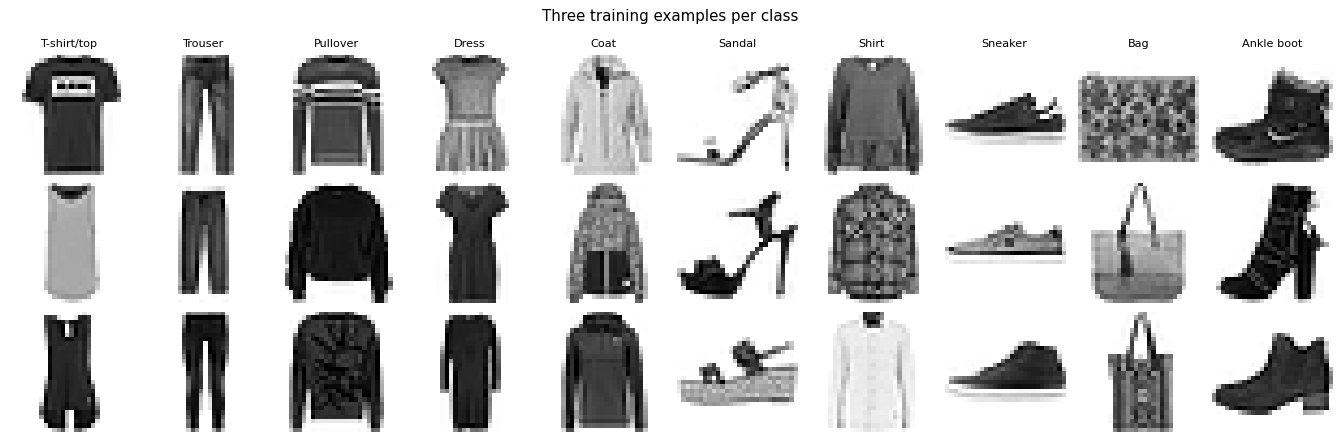

In [3]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for k in range(10):
    idx = np.where(train_labels == k)[0][:3]
    for r in range(3):
        axes[r, k].imshow(train_images[idx[r]], cmap="binary")
        axes[r, k].axis("off")
    axes[0, k].set_title(class_names[k], fontsize=9)
fig.suptitle("Three training examples per class")
plt.tight_layout(); plt.show()

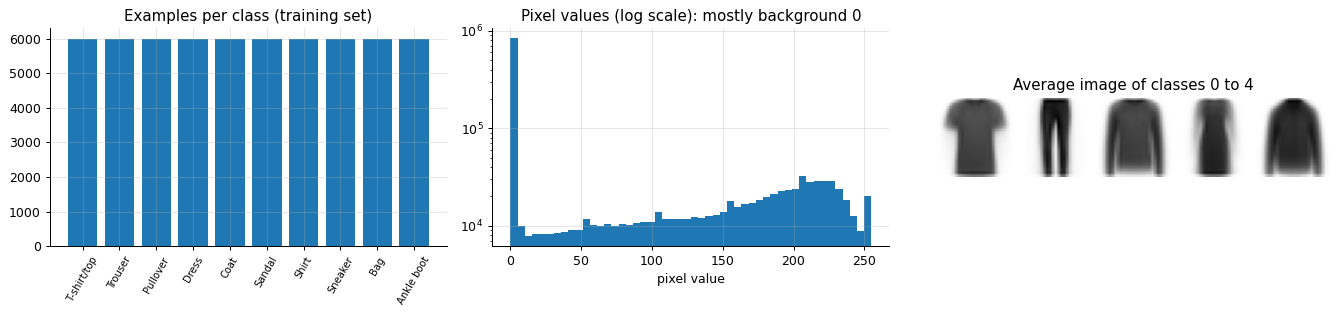

examples per class: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
counts = np.bincount(train_labels, minlength=10)
axes[0].bar(range(10), counts); axes[0].set_xticks(range(10)); axes[0].set_xticklabels(class_names, rotation=60, fontsize=8)
axes[0].set_title("Examples per class (training set)")

axes[1].hist(train_images[:2000].ravel(), bins=50, log=True)
axes[1].set_xlabel("pixel value"); axes[1].set_title("Pixel values (log scale): mostly background 0")

mean_imgs = np.stack([train_images[train_labels == k].mean(0) for k in range(10)])
axes[2].imshow(np.hstack(mean_imgs[:5]), cmap="binary"); axes[2].axis("off")
axes[2].set_title("Average image of classes 0 to 4")
plt.tight_layout(); plt.show()
print("examples per class:", counts)

- The classes are **perfectly balanced** (6000 each). Accuracy is therefore a fair summary metric, and guessing gives 10%.
- Most pixels are black background (0). The objects are centred and roughly the same size: the dataset is pre-processed.
- The average images already hint at which classes will be confused. T-shirt, pullover, coat and shirt have very similar silhouettes.

## 3. Training, validation and test sets

We need three sets, each with its own job:

| Set | Size | Used for |
|---|---|---|
| training | 55,000 | fitting the weights (gradient descent) |
| validation | 5,000 | choosing everything else: architecture, learning rate, number of epochs |
| test | 10,000 | **one** final, unbiased estimate of performance, at the very end |

Why not choose the number of epochs or the architecture on the test set? Every choice made by looking at a dataset fits that dataset a little. After many choices, the test accuracy would be optimistic, just as the training accuracy is. So we keep the test set locked away and hold out 5,000 training images for validation.

In [5]:
perm = np.random.default_rng(0).permutation(len(train_images))
val_idx, tr_idx = perm[:5000], perm[5000:]
X_tr_raw, y_tr = train_images[tr_idx], train_labels[tr_idx]
X_val_raw, y_val = train_images[val_idx], train_labels[val_idx]
print(f"train {len(X_tr_raw)}, validation {len(X_val_raw)}, test {len(test_images)}")

train 55000, validation 5000, test 10000


## 4. Pre-processing: scaling, standardising, flattening

**Scaling.** Pixels are integers in $[0, 255]$. We divide by 255 to get floats in $[0, 1]$.

**Standardising.** We then subtract the mean pixel value $\mu$ and divide by the standard deviation $\sigma$: $\tilde{x} = (x - \mu)/\sigma$. Inputs centred around 0 with unit spread keep the pre-activations $\mathbf{Z}^{[1]} = \mathbf{X}\mathbf{W}^{[1]} + \mathbf{b}^{[1]}$ of order 1 at initialisation, which is what PyTorch's default initialisation assumes. Training is usually faster and more stable. This is the same reason we standardised features for gradient descent in linear regression.

**Important:** $\mu$ and $\sigma$ are computed on the **training set only**, and then applied unchanged to validation and test. Computing them on all the data would let information from the test set leak into training (**data leakage**).

**Flattening.** An MLP takes a vector, so each $28 \times 28$ image becomes a vector of 784 numbers, row after row. The model does not know that pixel 29 sits just below pixel 1. We come back to this in section 13.

In [6]:
mu = (X_tr_raw / 255.0).mean()
sigma = (X_tr_raw / 255.0).std()
print(f"training pixel mean = {mu:.4f}, std = {sigma:.4f}")

def to_tensor(images):
    """uint8 (N, 28, 28) -> standardised float32 tensor (N, 28, 28)."""
    return torch.tensor((images / 255.0 - mu) / sigma, dtype=torch.float32)

X_tr, X_val, X_te = to_tensor(X_tr_raw), to_tensor(X_val_raw), to_tensor(test_images)
y_tr_t, y_val_t, y_te_t = (torch.tensor(a, dtype=torch.long) for a in (y_tr, y_val, test_labels))
print(f"after standardising: train mean {X_tr.mean():.3f}, std {X_tr.std():.3f}")
print("labels are int64 class indices, not one-hot vectors:", y_tr_t[:8], y_tr_t.dtype)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_tr, y_tr_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val_t), batch_size=1000)
test_loader = DataLoader(TensorDataset(X_te, y_te_t), batch_size=1000)
print(f"{len(train_loader)} training batches of {batch_size} per epoch")

training pixel mean = 0.2862, std = 0.3531


after standardising: train mean -0.000, std 1.000
labels are int64 class indices, not one-hot vectors: tensor([8, 0, 3, 1, 9, 9, 1, 5]) torch.int64
860 training batches of 64 per epoch


## 5. From sigmoid to softmax

For two classes the network had **one** output $z$ and we used $\hat{y} = \sigma(z) = P(y = 1 \mid \mathbf{x})$. For $K$ classes the last layer has **$K$ outputs** $z_1, \dots, z_K$, one score per class, called **logits**. The **softmax** turns them into a probability vector:

$$
\hat{p}_k = \text{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}, \qquad k = 1, \dots, K .
$$

The exponential makes every value positive, and dividing by the sum makes them add up to 1. The largest logit gets the largest probability, and the prediction is $\hat{y} = \arg\max_k \hat{p}_k = \arg\max_k z_k$. The softmax does not change which class wins: it only turns scores into probabilities.

**Property 1: adding a constant changes nothing.** For any number $c$,

$$
\text{softmax}(\mathbf{z} + c)_k = \frac{e^{z_k + c}}{\sum_j e^{z_j + c}} = \frac{e^{c}\,e^{z_k}}{e^{c}\sum_j e^{z_j}} = \text{softmax}(\mathbf{z})_k . \qquad\blacksquare
$$

Only the **differences** between logits matter. This gives the numerically stable implementation: subtract $\max_j z_j$ before exponentiating, so the largest exponent is $e^0 = 1$ and nothing overflows.

**Property 2: with two classes, softmax is the sigmoid.** For $K = 2$,

$$
\hat{p}_1 = \frac{e^{z_1}}{e^{z_0} + e^{z_1}} = \frac{1}{1 + e^{-(z_1 - z_0)}} = \sigma(z_1 - z_0) . \qquad\blacksquare
$$

So softmax is the natural generalisation of the sigmoid, and a 2-class softmax model is a logistic regression on the difference of the logits.

In [7]:
def softmax_naive(z):
    e = np.exp(z)
    return e / e.sum()

def softmax_stable(z):
    e = np.exp(z - z.max())          # Property 1: same result, no overflow
    return e / e.sum()

z = np.array([2.0, 1.0, 0.1])
print("logits           :", z)
print("softmax          :", softmax_stable(z).round(4), " sum =", softmax_stable(z).sum())
print("torch.softmax    :", torch.softmax(torch.tensor(z), dim=0).numpy().round(4))
print("logits + 100     :", softmax_stable(z + 100).round(4), " (unchanged)")

z_big = np.array([1000.0, 999.0, 0.0])
with np.errstate(over="ignore", invalid="ignore"):
    print("naive, big logits :", softmax_naive(z_big), " <- overflow: inf / inf = nan")
print("stable, big logits:", softmax_stable(z_big).round(4))

z2 = np.array([0.3, 1.5])
print(f"\nK = 2: softmax = {softmax_stable(z2)[1]:.4f},  sigmoid(z1 - z0) = {1 / (1 + np.exp(-(z2[1] - z2[0]))):.4f}")

logits           : [2.  1.  0.1]
softmax          : [0.659  0.2424 0.0986]  sum = 1.0
torch.softmax    : [0.659  0.2424 0.0986]
logits + 100     : [0.659  0.2424 0.0986]  (unchanged)
naive, big logits : [nan nan  0.]  <- overflow: inf / inf = nan
stable, big logits: [0.7311 0.2689 0.    ]

K = 2: softmax = 0.7685,  sigmoid(z1 - z0) = 0.7685


## 6. The loss: categorical cross-entropy

The model says $P(y = k \mid \mathbf{x}) = \hat{p}_k$. The probability it gives to the **observed** label $y$ is $\hat{p}_y$. Maximum likelihood over $m$ independent examples means maximising $\prod_i \hat{p}^{(i)}_{y^{(i)}}$, or equivalently minimising the mean negative log:

$$
\boxed{J = -\frac{1}{m}\sum_{i=1}^m \log \hat{p}^{(i)}_{y^{(i)}}}
$$

This is the **categorical cross-entropy**. Only the probability of the correct class appears. If $\hat{p}_y = 1$ the loss is 0. If $\hat{p}_y \to 0$ it grows without bound. With a one-hot vector $\mathbf{e}_y$ (1 at position $y$, 0 elsewhere) it reads $-\sum_k (\mathbf{e}_y)_k \log \hat{p}_k$, the general cross-entropy between two distributions. For $K = 2$ it is exactly the binary cross-entropy of the previous labs.

**In terms of logits.** Substituting the softmax:

$$
\ell(\mathbf{z}, y) = -\log\frac{e^{z_y}}{\sum_j e^{z_j}} = -z_y + \log\sum_{j=1}^K e^{z_j} .
$$

**The gradient (proof).** $\partial z_y / \partial z_k = \mathbb{1}[k = y]$, and $\frac{\partial}{\partial z_k}\log\sum_j e^{z_j} = \frac{e^{z_k}}{\sum_j e^{z_j}} = \hat{p}_k$. So

$$
\boxed{\frac{\partial \ell}{\partial z_k} = \hat{p}_k - \mathbb{1}[k = y]} \qquad\text{i.e.}\qquad \nabla_{\mathbf{z}}\,\ell = \hat{\mathbf{p}} - \mathbf{e}_y .
$$

Once again "prediction minus label". It pushes up the logit of the correct class (its gradient $\hat{p}_y - 1$ is negative) and pushes down every other logit in proportion to the probability it wrongly received.

**A useful sanity check.** A freshly initialised network outputs logits close to 0, so $\hat{p}_k \approx 1/K$ and the loss starts near $\log K = \log 10 \approx 2.303$. A very different starting loss means a bug, for example in the labels or the inputs.

**In PyTorch** there are two equivalent ways to compute it:
- `nn.CrossEntropyLoss()` on **raw logits**. It applies the (stable) log-softmax internally. This is what we use.
- `F.log_softmax` at the end of `forward`, then `nn.NLLLoss()` (negative log-likelihood). The original version of this lab did this.

The targets are class indices (`int64`), not one-hot vectors.

In [8]:
logits = torch.tensor([[2.0, 1.0, 0.1], [0.5, 2.5, -1.0]], requires_grad=True)
target = torch.tensor([0, 2])                       # true classes of the two examples

ce = nn.CrossEntropyLoss()(logits, target)
nll = nn.NLLLoss()(F.log_softmax(logits, dim=1), target)
by_hand = -torch.log_softmax(logits, dim=1)[torch.arange(2), target].mean()
print(f"CrossEntropyLoss = {ce.item():.4f},  log_softmax + NLLLoss = {nll.item():.4f},  by hand = {by_hand.item():.4f}")

ce.backward()
p = torch.softmax(logits, dim=1).detach()
expected = (p - F.one_hot(target, 3)) / 2           # (p - e_y) / m, because the loss is a mean
print("autograd gradient:\n", logits.grad)
print("(p - e_y) / m:\n", expected)

CrossEntropyLoss = 2.0351,  log_softmax + NLLLoss = 2.0351,  by hand = 2.0351
autograd gradient:
 tensor([[-0.1705,  0.1212,  0.0493],
        [ 0.0581,  0.4290, -0.4870]])
(p - e_y) / m:
 tensor([[-0.1705,  0.1212,  0.0493],
        [ 0.0581,  0.4290, -0.4870]])


## 7. Models: softmax regression and an MLP

We compare two models.

**Softmax regression** (a linear model, no hidden layer): $\mathbf{z} = \mathbf{x}\mathbf{W} + \mathbf{b}$ with $\mathbf{W} \in \mathbb{R}^{784 \times 10}$. Each class gets one weight per pixel, so it can only learn one "template" per class. It is the multiclass version of logistic regression and a strong baseline.

**MLP** with one hidden layer of 128 ReLU units:

$$
\mathbf{x} \in \mathbb{R}^{784} \xrightarrow{\;\mathbf{W}^{[1]},\, \mathbf{b}^{[1]}\;} \mathbb{R}^{128} \xrightarrow{\;\text{ReLU}\;} \mathbb{R}^{128} \xrightarrow{\;\mathbf{W}^{[2]},\, \mathbf{b}^{[2]}\;} \mathbf{z} \in \mathbb{R}^{10} .
$$

Both return **logits**, and the softmax lives inside the loss. `nn.Flatten()` turns a batch of shape $(m, 28, 28)$ into $(m, 784)$, the same as `x.view(-1, 784)`.

**Parameter count.** A linear layer from $n_{\text{in}}$ to $n_{\text{out}}$ units has $n_{\text{in}} n_{\text{out}}$ weights plus $n_{\text{out}}$ biases:
- softmax regression: $784 \cdot 10 + 10 = 7{,}850$;
- MLP: $(784 \cdot 128 + 128) + (128 \cdot 10 + 10) = 100{,}480 + 1{,}290 = 101{,}770$.

Almost all the MLP's parameters are in the first layer, which connects every pixel to every hidden unit.

The small `summary` helper below prints each layer's output shape and parameter count. It runs one dummy batch through the model and records shapes with **forward hooks**, functions PyTorch calls after each layer's forward pass.

In [9]:
class Net(nn.Module):
    """MLP 784 -> hidden -> 10 with ReLU. Returns logits."""
    def __init__(self, hidden=128):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, hidden)
        self.fc2 = nn.Linear(hidden, 10)

    def forward(self, x):
        x = self.flatten(x)          # (m, 28, 28) -> (m, 784)
        x = F.relu(self.fc1(x))      # (m, hidden)
        return self.fc2(x)           # (m, 10) logits

def softmax_regression():
    return nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def summary(model, input_shape=(1, 28, 28)):
    rows, hooks = [], []
    for name, mod in model.named_modules():
        if len(list(mod.children())) == 0:                  # leaf layers only
            hooks.append(mod.register_forward_hook(
                lambda m, i, o, name=name: rows.append((name, type(m).__name__, tuple(o.shape), sum(p.numel() for p in m.parameters())))))
    model.eval()
    with torch.no_grad():
        model(torch.zeros(1, *input_shape, device=next(model.parameters()).device))
    for h in hooks: h.remove()
    print(f"{'layer':<12}{'type':<12}{'output shape':<20}{'params':>10}")
    for r in rows: print(f"{r[0]:<12}{r[1]:<12}{str(r[2]):<20}{r[3]:>10,}")
    print(f"{'total':<44}{sum(p.numel() for p in model.parameters()):>10,}")

summary(Net()); print(); summary(softmax_regression())

layer       type        output shape            params
flatten     Flatten     (1, 784)                     0
fc1         Linear      (1, 128)               100,480
fc2         Linear      (1, 10)                  1,290
total                                          101,770

layer       type        output shape            params
0           Flatten     (1, 784)                     0
1           Linear      (1, 10)                  7,850
total                                            7,850


## 8. The training loop, with early stopping

The loop is the one from the PyTorch lab: for each mini-batch, `zero_grad` → forward → loss → `backward` → `step`. After each epoch we measure loss and accuracy on the validation set, in `eval` mode and without gradients.

**Early stopping.** Training longer always lowers the training loss, but at some point the validation loss starts rising: the model begins to memorise the training images. `fit` remembers the weights of the epoch with the **lowest validation loss** and restores them at the end. The number of epochs becomes a hyperparameter chosen on the validation set.

**Optimiser.** Adam with learning rate $10^{-3}$, its standard default. (The first version of this lab used $10^{-2}$, which is rather high for Adam and made the curves noisier.)

Two helpers compute the loss and accuracy over a whole `DataLoader`, and the predicted probabilities for a set of images.

In [10]:
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    """Mean loss and accuracy of the model over all batches of a loader."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            n += len(yb)
    return total_loss / n, correct / n

def predict_proba(model, X, batch=2000):
    """Softmax probabilities, shape (N, 10), as a NumPy array."""
    model.eval()
    with torch.no_grad():
        return torch.cat([torch.softmax(model(X[i:i + batch].to(device)), dim=1).cpu()
                          for i in range(0, len(X), batch)]).numpy()

def fit(model, train_loader, val_loader, epochs=15, lr=1e-3, weight_decay=0.0, verbose=True):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc")}
    best_loss, best_state, best_epoch = float("inf"), None, 0
    for epoch in range(epochs):
        model.train()
        tot, correct, n, t0 = 0.0, 0, 0, time.time()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            tot += loss.item() * len(yb); correct += (logits.argmax(1) == yb).sum().item(); n += len(yb)
        vl, va = evaluate(model, val_loader)
        for k, v in zip(hist, (tot / n, correct / n, vl, va)): hist[k].append(v)
        if vl < best_loss:
            best_loss, best_state, best_epoch = vl, copy.deepcopy(model.state_dict()), epoch
        if verbose:
            print(f"epoch {epoch + 1:2d}  train loss {tot / n:.4f} acc {correct / n:.4f}   "
                  f"val loss {vl:.4f} acc {va:.4f}   ({time.time() - t0:.1f}s)")
    model.load_state_dict(best_state)                    # early stopping: keep the best epoch
    if verbose:
        print(f"-> restored the weights of epoch {best_epoch + 1} (lowest validation loss)")
    hist["best_epoch"] = best_epoch
    return hist

torch.manual_seed(0)
mlp = Net().to(device)
print(f"loss before training: {evaluate(mlp, val_loader)[0]:.3f}   (log 10 = {np.log(10):.3f})\n")
hist_mlp = fit(mlp, train_loader, val_loader, epochs=15)

loss before training: 2.338   (log 10 = 2.303)



epoch  1  train loss 0.4754 acc 0.8279   val loss 0.4127 acc 0.8496   (0.7s)


epoch  2  train loss 0.3609 acc 0.8692   val loss 0.3602 acc 0.8604   (0.6s)


epoch  3  train loss 0.3261 acc 0.8801   val loss 0.3538 acc 0.8638   (0.6s)


epoch  4  train loss 0.3003 acc 0.8892   val loss 0.3277 acc 0.8810   (0.8s)


...

epoch 11  train loss 0.2087 acc 0.9215   val loss 0.3353 acc 0.8856   (0.6s)


epoch 12  train loss 0.2007 acc 0.9247   val loss 0.3309 acc 0.8834   (0.6s)


epoch 13  train loss 0.1922 acc 0.9274   val loss 0.3212 acc 0.8910   (0.6s)


epoch 14  train loss 0.1824 acc 0.9310   val loss 0.3282 acc 0.8868   (0.6s)


epoch 15  train loss 0.1772 acc 0.9327   val loss 0.3453 acc 0.8858   (0.6s)
-> restored the weights of epoch 10 (lowest validation loss)


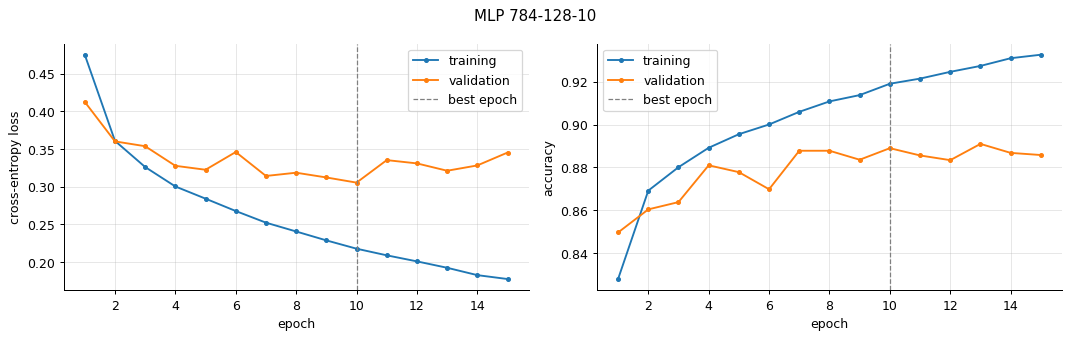

In [11]:
def plot_history(hist, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    ep = np.arange(1, len(hist["train_loss"]) + 1)
    for ax, key, name in [(axes[0], "loss", "cross-entropy loss"), (axes[1], "acc", "accuracy")]:
        ax.plot(ep, hist[f"train_{key}"], "o-", ms=3, label="training")
        ax.plot(ep, hist[f"val_{key}"], "o-", ms=3, label="validation")
        ax.axvline(hist["best_epoch"] + 1, color="gray", ls="--", lw=1, label="best epoch")
        ax.set_xlabel("epoch"); ax.set_ylabel(name); ax.legend()
    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_history(hist_mlp, "MLP 784-128-10")

**Reading the curves.** In the first epochs both losses fall together. Then the training loss keeps falling while the validation loss flattens and starts to creep up: the gap between the curves is **overfitting**. The model is getting better at the 55,000 images it trains on, but not at new ones. Early stopping keeps the weights from the dashed line.

Note that the validation **accuracy** can keep improving slightly while the validation **loss** rises. The loss also measures confidence: an overfitting model becomes over-confident on the images it gets wrong, which costs a lot of log-loss without changing the accuracy much.

For comparison we train the linear baseline with the same loop.

In [12]:
torch.manual_seed(0)
linear = softmax_regression().to(device)
hist_lin = fit(linear, train_loader, val_loader, epochs=15, verbose=False)
for name, h, mod in [("softmax regression", hist_lin, linear), ("MLP 784-128-10", hist_mlp, mlp)]:
    print(f"{name:<20} val acc at best epoch {h['val_acc'][h['best_epoch']]:.4f}  ({sum(p.numel() for p in mod.parameters()):,} parameters)")

softmax regression   val acc at best epoch 0.8522  (7,850 parameters)
MLP 784-128-10       val acc at best epoch 0.8890  (101,770 parameters)


The hidden layer adds a few points of accuracy over the linear model. On Fashion-MNIST that is a large gain: the remaining errors are concentrated in a few genuinely hard classes, as the next section shows.

## 9. Evaluation: accuracy, confusion matrix, per-class metrics, errors

All model choices are made, so now, and only now, we use the **test set**.

In [13]:
test_loss, test_acc = evaluate(mlp, test_loader)
print(f"MLP test loss {test_loss:.4f}, test accuracy {test_acc:.4f}")
print(f"softmax regression test accuracy {evaluate(linear, test_loader)[1]:.4f}")

probs_te = predict_proba(mlp, X_te)
pred_te = probs_te.argmax(1)

MLP test loss 0.3461, test accuracy 0.8843
softmax regression test accuracy 0.8404


**Confusion matrix.** Entry $(i, j)$ counts the test images of true class $i$ that the model predicted as class $j$. The diagonal holds the correct predictions. We normalise each row by the class size, so the diagonal is the **recall** of each class: the fraction of its images that are found.

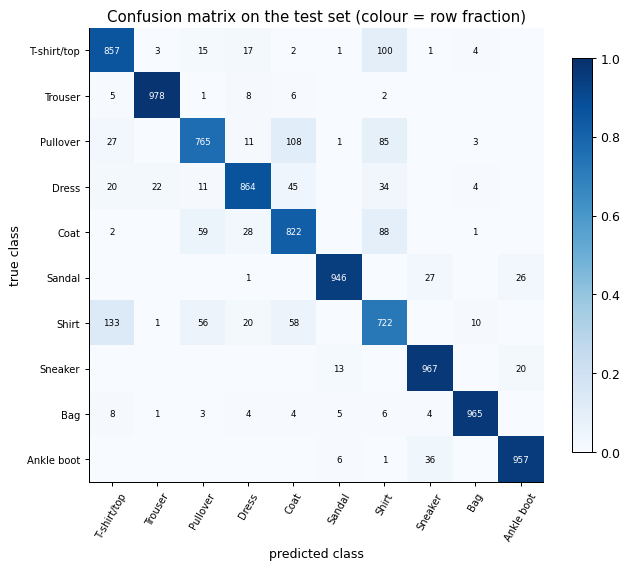

In [14]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(test_labels, pred_te)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if cm_norm[i, j] > 0.5 else "black")
ax.set_xticks(range(10)); ax.set_xticklabels(class_names, rotation=60, fontsize=8)
ax.set_yticks(range(10)); ax.set_yticklabels(class_names, fontsize=8)
ax.set_xlabel("predicted class"); ax.set_ylabel("true class"); ax.grid(False)
ax.set_title("Confusion matrix on the test set (colour = row fraction)")
fig.colorbar(im, shrink=0.8); plt.tight_layout(); plt.show()

In [15]:
print(classification_report(test_labels, pred_te, target_names=class_names, digits=3))

off = cm.copy(); np.fill_diagonal(off, 0)
print("most frequent confusions (true -> predicted):")
for flat in np.argsort(off.ravel())[::-1][:5]:
    i, j = divmod(flat, 10)
    print(f"  {class_names[i]:>12} -> {class_names[j]:<12} {off[i, j]:4d} images")

              precision    recall  f1-score   support

 T-shirt/top      0.815     0.857     0.835      1000
     Trouser      0.973     0.978     0.976      1000
    Pullover      0.841     0.765     0.801      1000
       Dress      0.907     0.864     0.885      1000
        Coat      0.787     0.822     0.804      1000
      Sandal      0.973     0.946     0.959      1000
       Shirt      0.696     0.722     0.709      1000
     Sneaker      0.934     0.967     0.950      1000
         Bag      0.978     0.965     0.971      1000
  Ankle boot      0.954     0.957     0.956      1000

    accuracy                          0.884     10000
   macro avg      0.886     0.884     0.885     10000
weighted avg      0.886     0.884     0.885     10000

most frequent confusions (true -> predicted):
         Shirt -> T-shirt/top   133 images
      Pullover -> Coat          108 images
   T-shirt/top -> Shirt         100 images
          Coat -> Shirt          88 images
      Pullover -> Shirt

**Precision, recall and F1 per class** (as in the logistic regression notes, now one class against the rest):
- **precision** of class $k$: of the images predicted as $k$, the fraction that really are $k$;
- **recall** of class $k$: of the images that are $k$, the fraction predicted as $k$;
- **F1**: their harmonic mean, $2PR/(P + R)$.

*Macro average* is the plain mean over classes, *weighted average* weights each class by its size. They are equal here because the classes are balanced.

The model is excellent on trousers, bags, sandals and sneakers, which have unique shapes. It struggles with **shirts**, which it confuses with T-shirts, pullovers and coats. Looking at a few of those images, even a person would hesitate.

**Where does the model go wrong, and how sure is it?** Below: the most confident mistakes, and the distribution of the predicted probability of the chosen class for correct and wrong predictions.

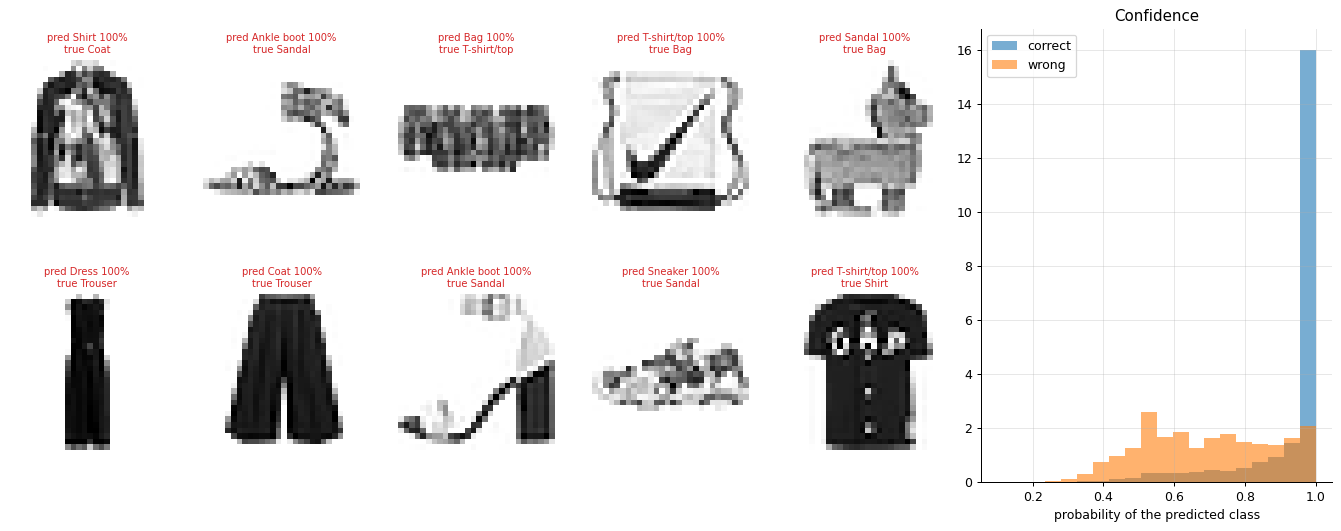

In [16]:
conf = probs_te.max(1)
wrong = np.where(pred_te != test_labels)[0]
worst = wrong[np.argsort(conf[wrong])[::-1][:10]]

fig = plt.figure(figsize=(15, 6))
for n, i in enumerate(worst):
    ax = fig.add_subplot(2, 7, n + 1 if n < 5 else n + 3)
    ax.imshow(test_images[i], cmap="binary"); ax.axis("off")
    ax.set_title(f"pred {class_names[pred_te[i]]} {conf[i]:.0%}\ntrue {class_names[test_labels[i]]}", fontsize=8, color="C3")
ax = fig.add_subplot(1, 7, (6, 7))
ax.hist(conf[pred_te == test_labels], bins=20, range=(0.1, 1), alpha=0.6, density=True, label="correct")
ax.hist(conf[wrong], bins=20, range=(0.1, 1), alpha=0.6, density=True, label="wrong")
ax.set_xlabel("probability of the predicted class"); ax.set_title("Confidence"); ax.legend()
plt.tight_layout(); plt.show()

Correct predictions are mostly made with probability close to 1, and wrong ones are spread over lower values. So the probability is informative: an image predicted at 55% deserves a second look. But some mistakes are made with almost 100% confidence. Look closely at them: several are genuinely ambiguous, and some look like **labelling errors** in the dataset (an obvious bag labelled as another class, for example). Real datasets always contain some label noise, and the most confident mistakes are the best place to find it. Neural networks trained with cross-entropy tend to be **over-confident**; checking and correcting that is called *calibration*.

## 10. Making predictions

To classify new images, apply exactly the same pre-processing as for training (divide by 255, standardise with the **training** $\mu$ and $\sigma$), run the model in `eval` mode without gradients, and apply the softmax to the logits.

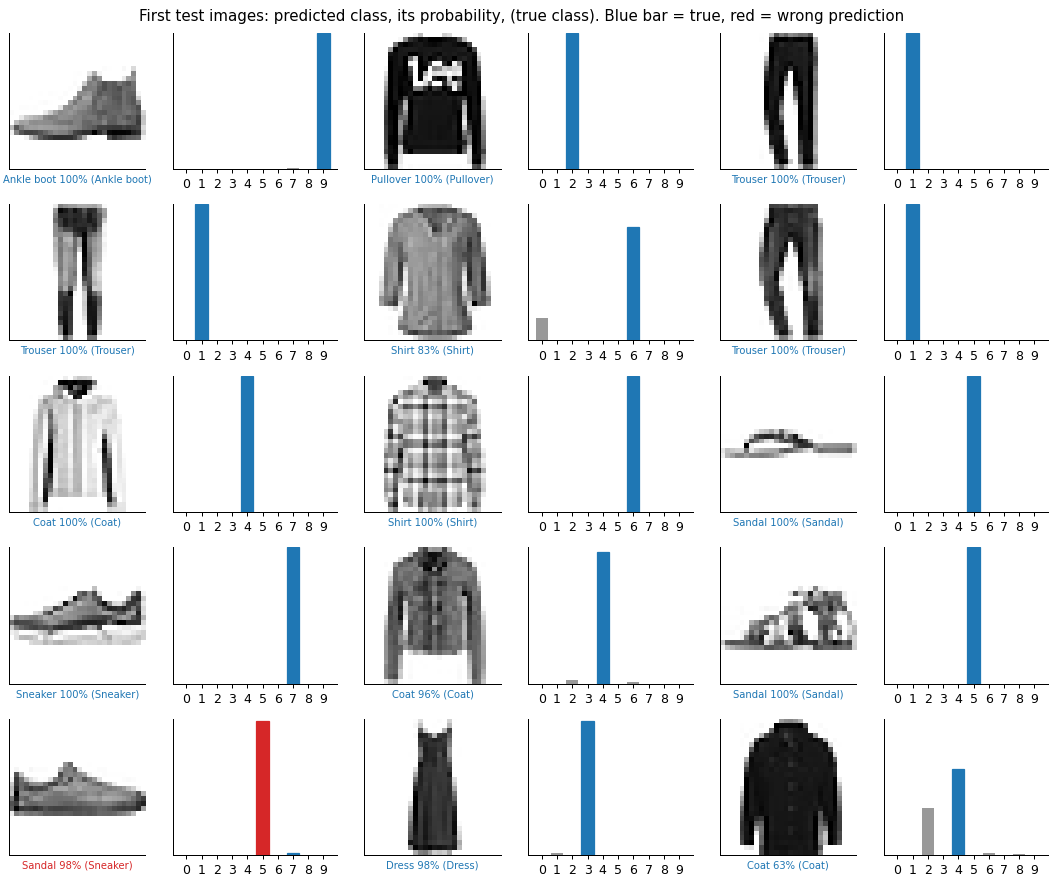

In [17]:
def plot_image(ax, i, probs, true_labels, images):
    pred = probs.argmax()
    color = "C0" if pred == true_labels[i] else "C3"
    ax.imshow(images[i], cmap="binary"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_xlabel(f"{class_names[pred]} {probs.max():.0%} ({class_names[true_labels[i]]})", color=color, fontsize=8)

def plot_value_array(ax, i, probs, true_labels):
    bars = ax.bar(range(10), probs, color="#999999")
    ax.set_ylim(0, 1); ax.set_xticks(range(10)); ax.set_yticks([]); ax.grid(False)
    bars[probs.argmax()].set_color("C3")
    bars[true_labels[i]].set_color("C0")

rows, cols = 5, 3
fig, axes = plt.subplots(rows, 2 * cols, figsize=(12, 10))
for n in range(rows * cols):
    r, c = divmod(n, cols)
    plot_image(axes[r, 2 * c], n, probs_te[n], test_labels, test_images)
    plot_value_array(axes[r, 2 * c + 1], n, probs_te[n], test_labels)
fig.suptitle("First test images: predicted class, its probability, (true class). Blue bar = true, red = wrong prediction")
plt.tight_layout(); plt.show()

**A single image.** Models always work on **batches**. One image of shape $(28, 28)$ must become a batch of one, with shape $(1, 28, 28)$: `img[None]` or `img.unsqueeze(0)`.

single image: (28, 28) -> as a batch: (1, 28, 28)
probabilities: [0.001 0.    0.996 0.    0.002 0.    0.    0.    0.    0.   ]  sum = 1.0
predicted: Pullover (99.6%),  true: Pullover


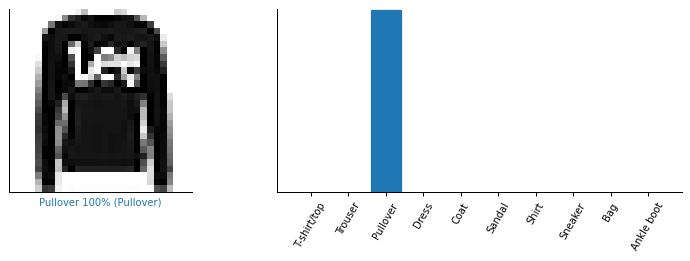

In [18]:
img = X_te[1]                                   # already standardised, shape (28, 28)
print("single image:", tuple(img.shape), "-> as a batch:", tuple(img.unsqueeze(0).shape))
mlp.eval()
with torch.no_grad():
    p_single = torch.softmax(mlp(img.unsqueeze(0).to(device)), dim=1).cpu().numpy()[0]
print("probabilities:", p_single.round(3), " sum =", p_single.sum().round(3))
print(f"predicted: {class_names[p_single.argmax()]} ({p_single.max():.1%}),  true: {class_names[test_labels[1]]}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
plot_image(axes[0], 1, p_single, test_labels, test_images)
plot_value_array(axes[1], 1, p_single, test_labels)
axes[1].set_xticklabels(class_names, rotation=60, fontsize=8)
plt.tight_layout(); plt.show()

## 11. What the network looks at: weights as images

Each unit of the first layer computes $\mathbf{x}^\top\mathbf{w} + b$, a weighted sum of the 784 pixels. Its weight vector $\mathbf{w}$ has one entry per pixel, so it can be displayed as a $28 \times 28$ image: red pixels push the unit up, blue pixels push it down.

For **softmax regression** these are the 10 class templates: the logit of class $k$ is large when the image matches template $k$.

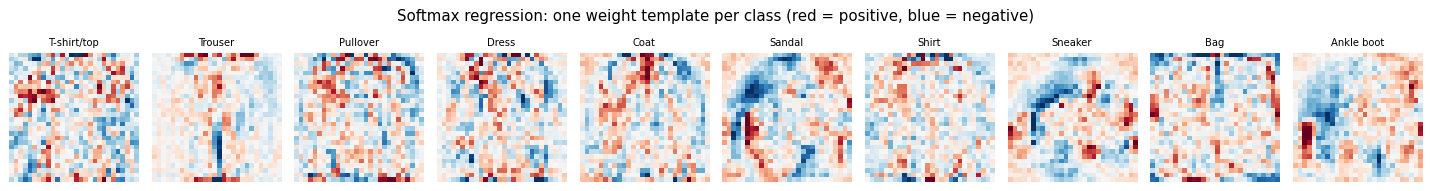

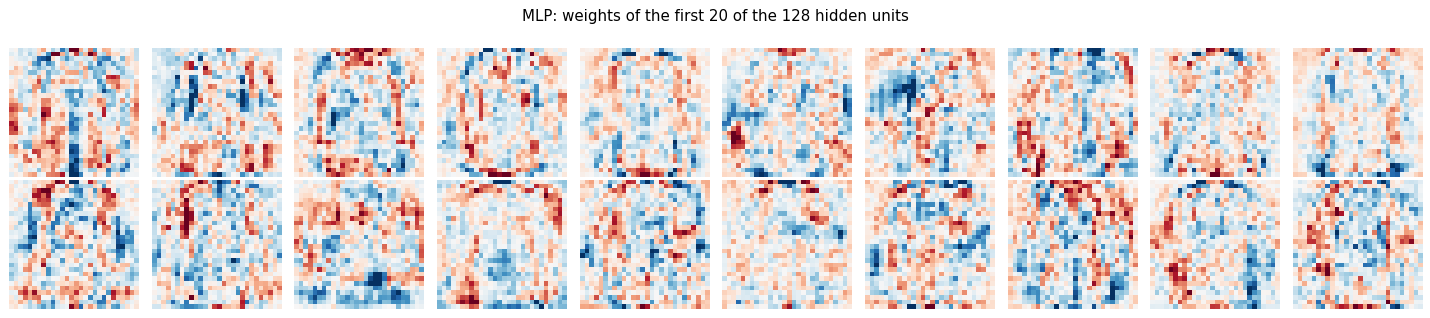

In [19]:
W = linear[1].weight.detach().cpu().numpy()           # (10, 784)
fig, axes = plt.subplots(1, 10, figsize=(16, 2.2))
for k, ax in enumerate(axes):
    lim = np.percentile(np.abs(W[k]), 99)             # robust colour scale: ignore a few extreme pixels
    ax.imshow(W[k].reshape(28, 28), cmap="RdBu_r", vmin=-lim, vmax=lim); ax.axis("off")
    ax.set_title(class_names[k], fontsize=8)
fig.suptitle("Softmax regression: one weight template per class (red = positive, blue = negative)")
plt.tight_layout(); plt.show()

W1 = mlp.fc1.weight.detach().cpu().numpy()             # (128, 784)
fig, axes = plt.subplots(2, 10, figsize=(16, 3.6))
for ax, w in zip(axes.ravel(), W1[:20]):
    l = np.percentile(np.abs(w), 99)
    ax.imshow(w.reshape(28, 28), cmap="RdBu_r", vmin=-l, vmax=l); ax.axis("off")
fig.suptitle("MLP: weights of the first 20 of the 128 hidden units")
plt.tight_layout(); plt.show()

The linear templates are noisy, but some structure is visible: the gap between the legs of a trouser, the outline and sole of the shoes, the top edge of a bag. Every pixel has its own weight, with no notion that neighbouring pixels are related, so the templates are not smooth. One template per class also cannot cover all the variations inside a class (long and short sleeves, different kinds of shoes).

The MLP's hidden units are **not** tied to one class. Each one detects some pattern (a region, an edge between regions, a part of a silhouette), and the output layer combines 128 of them. That richer set of features is where the extra accuracy comes from. The patterns are noisy because every unit sees every pixel with its own independent weight, including pixels that carry no information.

## 12. Experiments: width, depth and regularisation

Everything is decided on the **validation** set. Each model trains for 15 epochs with early stopping. The table reports the validation accuracy at the epoch with the lowest validation loss.

**Two regularisers** you can add in one line:
- **Dropout** (`nn.Dropout(p)`): during training, each hidden activation is set to 0 with probability $p$ and the survivors are multiplied by $1/(1-p)$, so the expected value is unchanged. No unit can rely on one specific partner, which reduces co-adaptation and overfitting. In `eval` mode dropout does nothing. That is why `model.train()` and `model.eval()` matter.
- **Weight decay** (`weight_decay=` in the optimiser): adds $\frac{\lambda}{2}\lVert\boldsymbol{\theta}\rVert^2$ to the loss, the L2 regularisation of the linear models. It keeps the weights small. (With Adam, `torch.optim.AdamW` applies it in a slightly better way.)

In [20]:
def mlp_model(hidden=(128,), dropout=0.0):
    layers, n_in = [nn.Flatten()], 784
    for h in hidden:
        layers += [nn.Linear(n_in, h), nn.ReLU()] + ([nn.Dropout(dropout)] if dropout > 0 else [])
        n_in = h
    return nn.Sequential(*layers, nn.Linear(n_in, 10))

experiments = {
    "linear (softmax regression)": (softmax_regression, 0.0),
    "MLP 32":                      (lambda: mlp_model((32,)), 0.0),
    "MLP 128":                     (lambda: mlp_model((128,)), 0.0),
    "MLP 512":                     (lambda: mlp_model((512,)), 0.0),
    "MLP 512-256":                 (lambda: mlp_model((512, 256)), 0.0),
    "MLP 512-256 + dropout 0.3":   (lambda: mlp_model((512, 256), dropout=0.3), 0.0),
}
exp_results = {}
print(f"{'model':<30}{'params':>10}{'val acc':>14}{'best epoch':>12}{'train acc there':>17}")
for name, (make, wd) in experiments.items():
    torch.manual_seed(0)
    model = make()
    h = fit(model, train_loader, val_loader, epochs=15, weight_decay=wd, verbose=False)
    b = h["best_epoch"]
    exp_results[name] = (model, h)
    print(f"{name:<30}{sum(p.numel() for p in model.parameters()):>10,}{h['val_acc'][b]:>14.4f}{b + 1:>12}{h['train_acc'][b]:>17.4f}")

model                             params       val acc  best epoch  train acc there


linear (softmax regression)        7,850        0.8522           8           0.8604


MLP 32                            25,450        0.8812          11           0.8984


MLP 128                          101,770        0.8906           9           0.9147


MLP 512                          407,050        0.8856           6           0.9074


MLP 512-256                      535,818        0.8834           6           0.9082


MLP 512-256 + dropout 0.3        535,818        0.8942          13           0.8982


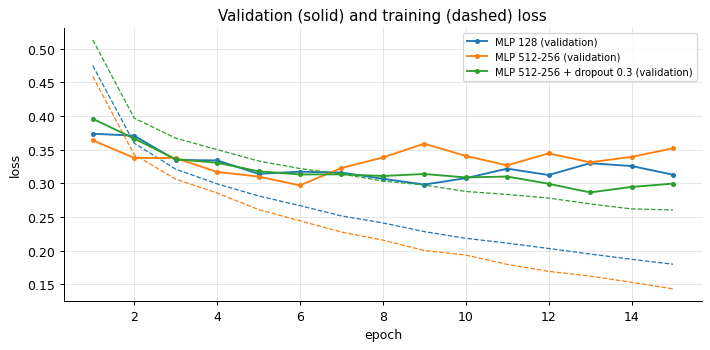

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
for name in ["MLP 128", "MLP 512-256", "MLP 512-256 + dropout 0.3"]:
    h = exp_results[name][1]
    l, = ax.plot(np.arange(1, 16), h["val_loss"], "o-", ms=3, label=f"{name} (validation)")
    ax.plot(np.arange(1, 16), h["train_loss"], "--", color=l.get_color(), lw=1)
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(fontsize=8)
ax.set_title("Validation (solid) and training (dashed) loss")
plt.tight_layout(); plt.show()

What to take from the table and the plot:
- **Capacity helps, then stops helping.** Going from linear to one hidden layer of 32 units gives the largest jump. 128 units help a little more. Wider or deeper networks without regularisation are **not** better here, although they have 4 to 5 times more parameters.
- **Bigger networks overfit sooner.** Their training loss drops faster and their validation loss turns up earlier, so early stopping picks an earlier epoch.
- **Dropout fixes that.** With dropout the training loss falls more slowly, because the task is harder during training. The validation loss keeps improving for longer, and the large network becomes the best one in the table. Large network plus regularisation is the usual recipe in deep learning.

An MLP on Fashion-MNIST tops out at around 89 to 90% accuracy. To go clearly beyond that, the model needs to know that the input is an **image**.

## 13. The limit of MLPs on images: shifting the picture

For an MLP, pixel number 300 is just feature number 300. If we move every image 2 pixels to the right, a person sees the same clothes, but the MLP receives a completely different input vector: every feature now holds the value of another pixel. Let us measure the effect on the test set.

linear (softmax regression)    shift 0: 0.840  shift 1: 0.741  shift 2: 0.520  shift 3: 0.306  shift 4: 0.216  shift 5: 0.224


MLP 128                        shift 0: 0.883  shift 1: 0.804  shift 2: 0.532  shift 3: 0.334  shift 4: 0.257  shift 5: 0.266
MLP 512-256 + dropout 0.3      shift 0: 0.889  shift 1: 0.819  shift 2: 0.587  shift 3: 0.360  shift 4: 0.261  shift 5: 0.238


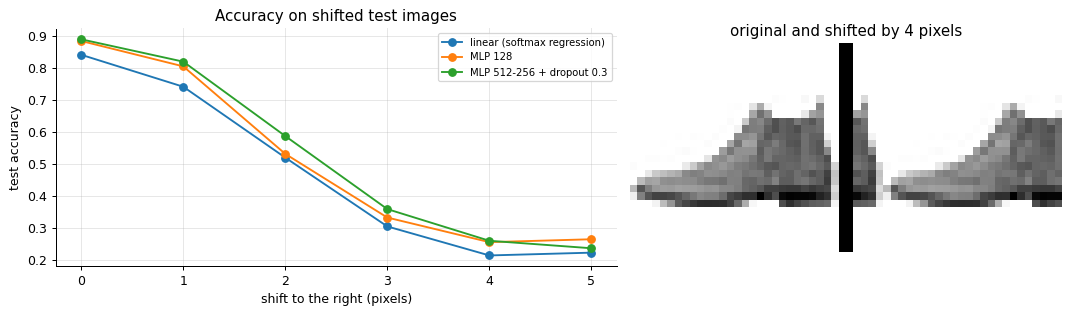

In [22]:
def shift_images(X, dx):
    """Shift images dx pixels to the right, filling with background."""
    if dx == 0:
        return X
    background = X.min()                     # the standardised value of a black pixel
    out = torch.full_like(X, background)
    out[:, :, dx:] = X[:, :, :-dx]
    return out

shifts = [0, 1, 2, 3, 4, 5]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.3, 1]})
for name in ["linear (softmax regression)", "MLP 128", "MLP 512-256 + dropout 0.3"]:
    model = exp_results[name][0]
    accs = [evaluate(model, DataLoader(TensorDataset(shift_images(X_te, s), y_te_t), batch_size=1000))[1] for s in shifts]
    axes[0].plot(shifts, accs, "o-", label=name)
    print(f"{name:<30}", "  ".join(f"shift {s}: {a:.3f}" for s, a in zip(shifts, accs)))
axes[0].set_xlabel("shift to the right (pixels)"); axes[0].set_ylabel("test accuracy"); axes[0].legend(fontsize=8)
axes[0].set_title("Accuracy on shifted test images")
axes[1].imshow(np.hstack([test_images[0], np.full((28, 2), 255), np.roll(test_images[0], 4, axis=1)]), cmap="binary")
axes[1].axis("off"); axes[1].set_title("original and shifted by 4 pixels")
plt.tight_layout(); plt.show()

A shift of a few pixels, invisible to a person, makes the accuracy collapse. The MLP has learned *where* things usually are in these perfectly centred images, not *what* they look like. Because each weight is attached to one pixel position, the network would need to see every object at every position to learn to recognise it everywhere.

This is the motivation for **convolutional neural networks** (next lab, *Demo_CNN_Multiclass*). They slide the same small filter over every position of the image. This builds in two facts about images that the MLP ignores: nearby pixels belong together (**locality**), and a pattern means the same thing wherever it appears (**weight sharing**). They get higher accuracy with far fewer parameters.

## 14. Summary

- For $K$ classes the network outputs $K$ **logits**, and the **softmax** $\hat{p}_k = e^{z_k}/\sum_j e^{z_j}$ turns them into probabilities. Only differences between logits matter, and for $K = 2$ the softmax is the sigmoid.
- **Categorical cross-entropy** $J = -\frac{1}{m}\sum_i \log\hat{p}^{(i)}_{y^{(i)}}$ is the negative log-likelihood. Its gradient with respect to the logits is $\hat{\mathbf{p}} - \mathbf{e}_y$. It starts near $\log K$.
- In PyTorch: return logits and use `nn.CrossEntropyLoss` with integer class labels (or `log_softmax` + `NLLLoss`, which is the same).
- Use three sets: train to fit, validation to choose (including the epoch, by **early stopping**), test once at the end. Compute pre-processing statistics on the training set only.
- Evaluate with more than accuracy: the confusion matrix, per-class precision and recall, and the model's most confident errors.
- MLPs flatten the image and treat each pixel as an unrelated feature. They are sensitive to shifts, which is what CNNs fix.

## Exercises

Try each one before opening the answer.

1. **Spatial information.** Shuffle the 784 pixel positions with one fixed random permutation, applied to every train and test image, and retrain the MLP. What accuracy do you expect? Why? What would happen to a CNN?
2. **Softmax and maximum likelihood.** Show that minimising the cross-entropy is the same as maximising the likelihood of a categorical model. Why is it the right loss for multiclass classification?
3. **Starting loss.** A classmate's network starts training with a loss of 23. Give two possible causes.
4. **Batch size.** What happens to the learning curves, the time per epoch and the memory use if you increase the batch size from 64 to 1024 while keeping the learning rate?
5. **Overfitting.** Besides dropout, weight decay and early stopping, list two more ways to reduce overfitting on this problem.
6. **Test set discipline.** Why did we choose the epoch by the validation loss and not by the test accuracy, even though the test set is larger?

<details>
<summary><b>Answers</b></summary>

**1.** About the **same** accuracy as before. The MLP has no idea which pixels are neighbours: a fixed permutation just renames its input features, and the network can learn the permuted weights equally well. This shows that the MLP does not use the 2-D structure at all. A CNN would get much worse, because its filters rely on neighbouring pixels being related, and the permutation destroys that.

**2.** A categorical model says $P(y = k \mid \mathbf{x}) = \hat{p}_k$, so the likelihood of $m$ independent examples is $\prod_i \hat{p}^{(i)}_{y^{(i)}}$. Taking $-\frac{1}{m}\log$ turns the product into the sum $-\frac{1}{m}\sum_i\log\hat{p}^{(i)}_{y^{(i)}}$, which is the cross-entropy. The log is increasing and $-\frac{1}{m}$ is a negative constant, so the minimiser of one is the maximiser of the other. It is the right loss because it rewards putting probability on the correct class, penalises confident mistakes heavily, and has the simple gradient $\hat{\mathbf{p}} - \mathbf{e}_y$.

**3.** A starting loss far above $\log 10 \approx 2.3$ means the initial logits are huge, so the network is confidently wrong from the start. The two usual causes are inputs that were not scaled (pixels in $[0, 255]$ instead of roughly $[-1, 3]$, so $\mathbf{Z}^{[1]}$ is about 100 times too large) and weights initialised far too large. Both are fixed by pre-processing and the default initialisation.

**4.** With batch 1024 there are 16 times fewer steps per epoch. Each step is more accurate but, at the same learning rate, progress per epoch is slower, so the curves drop more slowly per epoch. They are also smoother. Each epoch is faster on a GPU (fewer, bigger, parallel operations). Memory grows roughly linearly with the batch size, because the activations of the whole batch are stored for the backward pass. A common heuristic is to scale the learning rate up with the batch size.

**5.** Data augmentation (small shifts, flips, which the next lab uses), more training data, a smaller network, or an architecture with the right built-in assumptions (a CNN), which reaches a better accuracy with fewer parameters. Ensembles of several models also generalise better than a single one.

**6.** Choosing the epoch is fitting a hyperparameter. If we chose it on the test set, the test accuracy would be the maximum over 15 noisy measurements and therefore optimistic. It would no longer be an honest estimate of performance on new data. The test set is used once, after all decisions are made. Its size does not change this.

</details>